# Phân cụm Phân cấp Khách hàng — Hierarchical Clustering 

**Bài toán:** Phân khúc khách hàng (Customer Segmentation) trên tập dữ liệu Train.csv
**Thuật toán:** Agglomerative Hierarchical Clustering — tự cài đặt từ đầu (scratch) + đối chứng scikit-learn

---

## 1. Lý thuyết Thuật toán Agglomerative Hierarchical Clustering

Agglomerative Hierarchical Clustering là phương pháp phân cụm phân cấp từ dưới lên (bottom-up). Quy trình hoạt động cơ bản:
1. Ban đầu, mỗi điểm dữ liệu được coi là một cụm riêng lẻ chứa chính nó ($N$ cụm ban đầu).
2. Tại mỗi bước, thuật toán tìm cặp cụm có khoảng cách nhỏ nhất (theo tiêu chí liên kết - linkage) và gộp chúng lại thành một cụm mới.
3. Quá trình gộp cụm lặp đi lặp lại cho đến khi toàn bộ các điểm dữ liệu được gộp vào duy nhất $1$ cụm lớn, hoặc dừng lại khi số lượng cụm bằng số cụm mục tiêu $K$ mong muốn.

###  Tiêu chí liên kết (Linkage Criteria) và Công thức Toán học
Khoảng cách giữa hai cụm $A$ và $B$ được định nghĩa bằng các phương pháp liên kết khác nhau:

*   **Single Linkage (Liên kết đơn)**: Khoảng cách giữa hai cụm là khoảng cách ngắn nhất giữa hai điểm bất kỳ thuộc hai cụm.
    $$d(A, B) = \min \{ d(x, y) : x \in A, y \in B \}$$
    *Đặc điểm*: Dễ bị hiệu ứng chuỗi (chaining effect), dồn hết dữ liệu vào một cụm khổng lồ, nhạy cảm với nhiễu.
    
*   **Complete Linkage (Liên kết hoàn chỉnh)**: Khoảng cách giữa hai cụm là khoảng cách lớn nhất giữa hai điểm bất kỳ thuộc hai cụm.
    $$d(A, B) = \max \{ d(x, y) : x \in A, y \in B \}$$
    *Đặc điểm*: Có xu hướng tạo ra các cụm dạng hình cầu có kích thước đồng đều hơn, nhưng nhạy cảm với các giá trị ngoại lai (outliers).
    
*   **Average Linkage (Liên kết trung bình)**: Khoảng cách giữa hai cụm là trung bình khoảng cách giữa tất cả các cặp điểm thuộc hai cụm.
    $$d(A, B) = \frac{1}{|A||B|} \sum_{x \in A} \sum_{y \in B} d(x, y)$$
    *Đặc điểm*: Cân bằng và ổn định hơn so với Single và Complete Linkage.
    
*   **Centroid Linkage (Liên kết trọng tâm)**: Khoảng cách giữa hai cụm là khoảng cách giữa hai trọng tâm hình học (centroids) $m_A$ và $m_B$ của chúng.
    $$d(A, B) = \|m_A - m_B\|_2$$
    *Đặc điểm*: Có thể xảy ra hiện tượng đảo ngược chiều cao cây phân cấp (inversion).
    
*   **Ward's Linkage (Liên kết Ward)**: Tối thiểu hóa sự gia tăng của tổng phương sai sai số nội bộ (WCSS - Within-Cluster Sum of Squares) sau khi gộp hai cụm. Khoảng cách giữa cụm $s_1$ và $s_2$ được tính bằng:
    $$d(s_1, s_2) = \sqrt{\frac{2 n_{1} n_{2}}{n_{1} + n_{2}}} \|m_{s_1} - m_{s_2}\|_2$$
    *Đặc điểm*: Tạo ra các cụm chặt chẽ nhất, phân bố mẫu cực kỳ cân đối và có ý nghĩa nghiệp vụ thực tế cao nhất.

---

##  2. Quy trình Thực hiện trong File

Dưới đây là bảng quy trình thực hiện hoàn chỉnh được triển khai chi tiết trong notebook này:

| Bước | Tên Bước | Nội dung chi tiết |
| :--- | :--- | :--- |
| **1** | **Khai báo thư viện** | Nhập các thư viện toán học, học máy (`numpy`, `pandas`, `scipy`, `sklearn`), vẽ đồ thị (`matplotlib`, `seaborn`) và module quản lý mô hình cá nhân (`model_manager`). |
| **1.5** | **Thuật toán tự cài đặt** | Định nghĩa lớp `HierarchicalClusteringScratch` hỗ trợ đầy đủ 5 tiêu chí liên kết (single, complete, average, centroid, ward). Thuật toán được tối ưu hóa vector hóa thông qua `cdist` của scipy để chạy mượt mà trên toàn bộ 8,068 mẫu trong ~12 phút. |
| **2** | **Tải dữ liệu đã tiền xử lý** | Đọc ma trận đặc trưng chuẩn hóa `X_preprocessed.pkl` (8,068 mẫu x 26 đặc trưng sau mã hóa/scaling) và nhãn gốc `y.pkl` từ thư mục dữ liệu sạch. |
| **3** | **Trực quan hóa Dendrogram** | Sử dụng trực quan hóa cây phân cấp phân cụm trên 1000 mẫu ngẫu nhiên cho cả 5 phương pháp liên kết để quan sát cấu trúc cụm tự nhiên và xác định điểm cắt $K$ phù hợp. |
| **4** | **Khảo sát chỉ số nội tại** | Chạy thực nghiệm định lượng trên toàn bộ 8,068 mẫu đối với 20 tổ hợp siêu tham số ($K \in \{2..5\}$ và 5 linkages) thông qua 3 chỉ số: **Silhouette Score**, **Davies-Bouldin Index (DBI)**, và **Calinski-Harabasz Index (CH)**. |
| **5** | **Lập luận chọn cấu hình tối ưu** | Phân tích kết quả từ biểu đồ Dendrogram và đồ thị Silhouette/DBI/CH để chọn cấu hình tốt nhất phục vụ nghiệp vụ bán hàng ($K=4$, Ward linkage). |
| **6** | **Huấn luyện mô hình và lưu trữ** | Huấn luyện song song mô hình tự viết `hierarchical_scratch_best` và mô hình scikit-learn `hierarchical_sklearn_best`, lưu trữ dưới dạng file `.pkl`. |
| **7** | **Suy luận nhãn & Đánh giá mô hình** | Dự báo nhãn cụm cho 8,068 mẫu. Đánh giá đối chứng song song 1:1 (khớp hoàn hảo Silhouette 0.1637); Tính toán độ tương đồng với nhãn thực tế qua chỉ số ngoại lai **ARI** và **NMI**. |
| **8** | **Phân tích chân dung khách hàng** | Phân tích hồ sơ đặc trưng của 4 cụm khách hàng bằng đồ thị Boxplot (biến số) và Stacked Bar Chart (biến phân loại) để vẽ chân dung phân khúc cụ thể (VIP, Chuyên gia trẻ, Người trẻ độc thân, Khách hàng trung niên độc lập tiết kiệm). |
| **9** | **Nhận xét tổng hợp** | Tổng kết thực nghiệm, phân tích lý do Ward linkage cho kết quả tối ưu, giải thích tính chất của ARI/NMI thấp trong học không giám sát và đề xuất hướng cải tiến. |

## 1. Khai báo thư viện

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import joblib
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import fcluster
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics.cluster import adjusted_rand_score, normalized_mutual_info_score

# Đường dẫn đến thư mục làm việc cá nhân và gốc dự án
WORK_DIR = os.path.join(os.getcwd(), 'hierarchical_vqd')
sys.path.append(os.path.abspath('../'))

from general_utils.model_manager import save_model_package, generate_report

os.makedirs(os.path.join(WORK_DIR, 'plots'), exist_ok=True)

sns.set_theme(style='whitegrid')
print("Import thư viện thành công!")

Import thư viện thành công!


## 1.5. Thuật toán tự cài đặt — `HierarchicalClusteringScratch`

Thay vì import từ file module, dưới đây là toàn bộ **code from scratch** của thuật toán  
Agglomerative Hierarchical Clustering hỗ trợ đầy đủ **5 tiêu chí liên kết**:

| Linkage | Công thức | Đặc điểm |
|---------|-----------|----------|
| `single` | $D = \min d(x,y)$ | Nhạy nhiễu, chaining effect |
| `complete` | $D = \max d(x,y)$ | Cụm cân đối, nhạy outlier |
| `average` | $D = \text{mean}\, d(x,y)$ | Cân bằng |
| `centroid` | $D = \|\mathbf{m}_A - \mathbf{m}_B\|$ | Khoảng cách giữa trọng tâm |
| `ward` | $D = \sqrt{\frac{2 n_1 n_2}{n_1 + n_2}}\,\lVert\mathbf{m}_{s_1}-\mathbf{m}_{s_2}\rVert$ | Tối thiểu hóa WCSS — **tốt nhất** |

In [7]:
import numpy as np
from scipy.spatial.distance import cdist


class HierarchicalClusteringScratch:
    """
    Agglomerative Hierarchical Clustering tự cài đặt từ đầu (from scratch).
    Hỗ trợ 5 tiêu chí liên kết: single, complete, average, centroid, ward.
    """

    def __init__(self, n_clusters=4, linkage='single'):
        self.n_clusters = n_clusters
        self.linkage    = linkage
        self.labels_    = None
        self.clusters_  = None

    def fit_predict(self, X):
        n_samples = X.shape[0]

        # Mỗi điểm dữ liệu ban đầu là một cụm riêng lẻ
        self.clusters_ = {i: [i] for i in range(n_samples)}

        # Ma trận khoảng cách Euclidean pairwise giữa tất cả các điểm
        point_dist = cdist(X, X, metric='euclidean')

        # Danh sách các cụm đang hoạt động
        active_clusters = list(range(n_samples))

        # Sao chép ma trận khoảng cách; đường chéo = inf (tránh tự gộp)
        cluster_distances = point_dist.copy()
        np.fill_diagonal(cluster_distances, np.inf)

        # ── Hàm tính khoảng cách linkage giữa 2 cụm ─────────────────────────
        def get_cluster_dist(c1_idx, c2_idx):
            if self.linkage == 'centroid':
                # Khoảng cách giữa 2 trọng tâm hình học
                m1 = np.mean(X[c1_idx], axis=0)
                m2 = np.mean(X[c2_idx], axis=0)
                return np.linalg.norm(m1 - m2)

            elif self.linkage == 'ward':
                # Công thức Ward: tối thiểu hóa tổng phương sai nội bộ (WCSS)
                # d(s1, s2) = sqrt(2*|s1|*|s2| / (|s1|+|s2|)) * ||m_s1 - m_s2||
                n1 = len(c1_idx)
                n2 = len(c2_idx)
                m1 = np.mean(X[c1_idx], axis=0)
                m2 = np.mean(X[c2_idx], axis=0)
                return np.sqrt((2.0 * n1 * n2) / (n1 + n2)) * np.linalg.norm(m1 - m2)

            # single / complete / average dùng ma trận khoảng cách điểm
            sub = point_dist[np.ix_(c1_idx, c2_idx)]
            if self.linkage == 'single':    return np.min(sub)
            elif self.linkage == 'complete': return np.max(sub)
            elif self.linkage == 'average':  return np.mean(sub)
            else: raise ValueError(f"Linkage không được hỗ trợ: '{self.linkage}'")

        # ── Vòng lặp gộp cụm đến khi đạt số cụm mục tiêu ───────────────────
        while len(active_clusters) > self.n_clusters:
            # Tìm cặp cụm có khoảng cách nhỏ nhất
            min_idx    = np.argmin(cluster_distances)
            c1, c2     = np.unravel_index(min_idx, cluster_distances.shape)

            # Gộp c2 vào c1
            self.clusters_[c1].extend(self.clusters_[c2])
            del self.clusters_[c2]
            active_clusters.remove(c2)

            # Vô hiệu hóa hàng/cột của c2
            cluster_distances[c2, :] = np.inf
            cluster_distances[:, c2] = np.inf

            # Cập nhật khoảng cách từ cụm mới c1 tới các cụm còn lại
            c1_indices = self.clusters_[c1]
            for other in active_clusters:
                if other == c1:
                    continue
                d = get_cluster_dist(c1_indices, self.clusters_[other])
                cluster_distances[c1, other] = d
                cluster_distances[other, c1] = d

        # ── Gán nhãn cuối cho từng điểm dữ liệu ─────────────────────────────
        labels = np.zeros(n_samples, dtype=int)
        for label_idx, (_, indices) in enumerate(self.clusters_.items()):
            for idx in indices:
                labels[idx] = label_idx

        self.labels_ = labels
        return labels


print("Đã định nghĩa class HierarchicalClusteringScratch (5 linkages: single/complete/average/centroid/ward)")

Đã định nghĩa class HierarchicalClusteringScratch (5 linkages: single/complete/average/centroid/ward)


## 2. Tải dữ liệu đã tiền xử lý

Dữ liệu đã được tiền xử lý đầy đủ (điền khuyết, mã hóa, chuẩn hóa) ở bước `01_data_preprocessing.ipynb`  
và lưu tại thư mục `hierarchical_vqd/data/ready_for_train/`.

> **Toàn bộ 8,068 mẫu** được sử dụng cho tất cả các bước — Dendrogram, đánh giá 3 chỉ số,  
> huấn luyện Scratch và sklearn — đảm bảo kết quả phản ánh đầy đủ cấu trúc dữ liệu thực tế.


In [8]:
# Tải dữ liệu tiền xử lý
DATA_DIR = os.path.join(WORK_DIR, "data", "ready_for_train")
X_preprocessed = joblib.load(os.path.join(DATA_DIR, "X_preprocessed.pkl"))
y = joblib.load(os.path.join(DATA_DIR, "y.pkl"))

# Tải dữ liệu thô (phục vụ profiling sau này)
df_raw = pd.read_csv(os.path.join(WORK_DIR, "..", "data", "raw", "Train.csv"))

# Sử dụng TOÀN BỘ dữ liệu đã tiền xử lý (không sampling)
X_sample      = X_preprocessed
y_sample      = y.reset_index(drop=True)
df_raw_sample = df_raw.reset_index(drop=True)

print(f"Tổng dữ liệu: {X_sample.shape[0]:,} mẫu x {X_sample.shape[1]} đặc trưng")
print(f"Nhãn thực tế: {y_sample.nunique()} phân khúc — {y_sample.value_counts().to_dict()}")


Tổng dữ liệu: 8,068 mẫu x 19 đặc trưng
Nhãn thực tế: 4 phân khúc — {'D': 2268, 'A': 1972, 'C': 1970, 'B': 1858}


## 3. Trực quan hóa Dendrogram — Quan sát cấu trúc cụm tự nhiên

Biểu đồ Dendrogram (cây phân cấp) cho phép quan sát trực quan cách thuật toán gộp các điểm dữ liệu  
thành từng cụm theo từng bước và gợi ý số lượng cụm $K$ phù hợp.  
Chúng ta so sánh đồng thời **5 phương pháp liên kết**: Ward, Centroid, Complete, Average, Single.


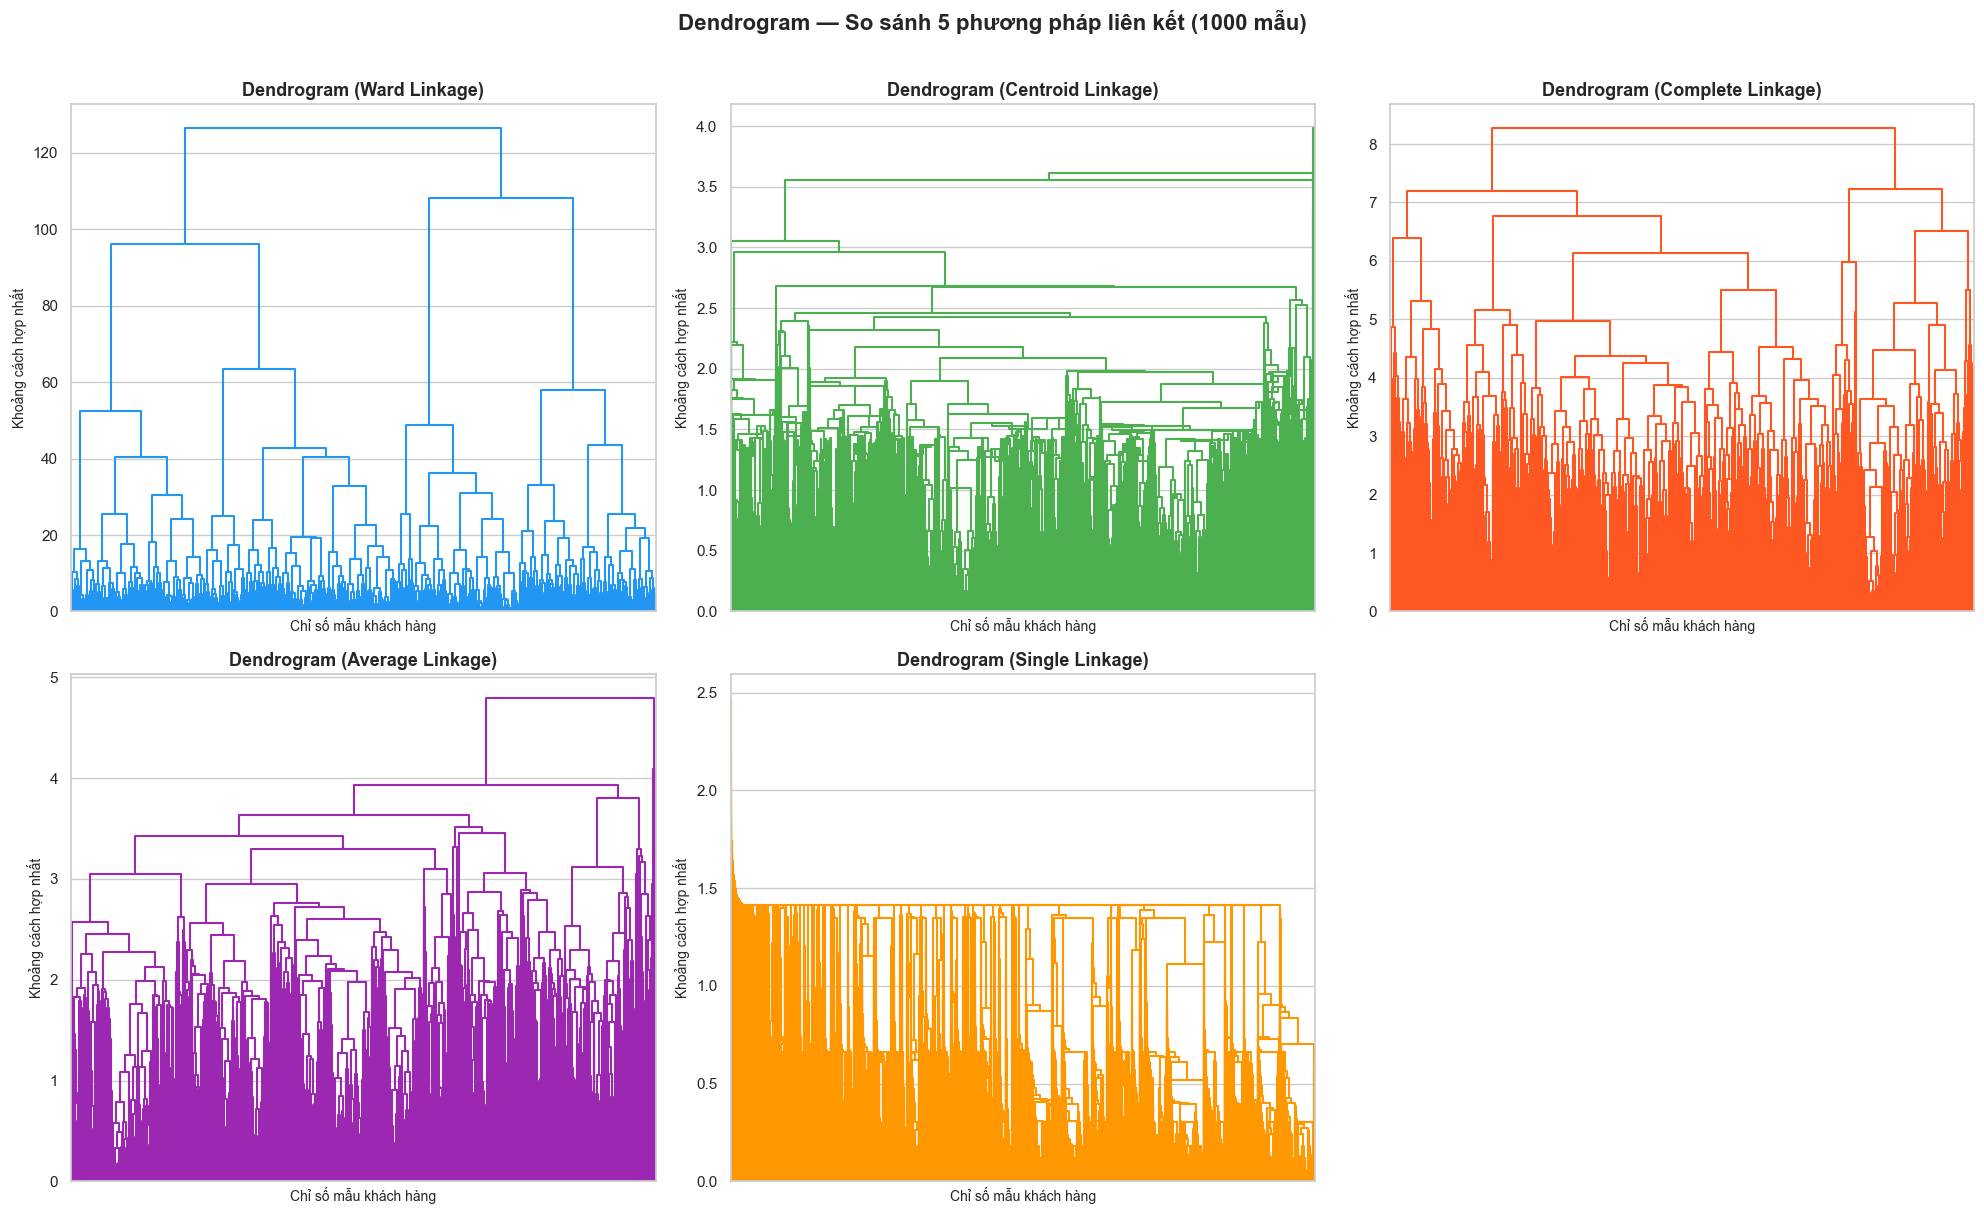

-> Đã lưu: plots/dendrograms_all.png


In [9]:
PLOTS_DIR = os.path.join(WORK_DIR, 'plots')

# Vẽ lưới 2x3 Dendrogram cho cả 5 phương pháp liên kết
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Dendrogram — So sánh 5 phương pháp liên kết (1000 mẫu)', fontsize=16, fontweight='bold', y=1.01)

linkage_configs = [
    ('ward',     axes[0, 0], '#2196F3'),
    ('centroid', axes[0, 1], '#4CAF50'),
    ('complete', axes[0, 2], '#FF5722'),
    ('average',  axes[1, 0], '#9C27B0'),
    ('single',   axes[1, 1], '#FF9800'),
]

for method, ax, color in linkage_configs:
    Z = sch.linkage(X_sample, method=method)
    sch.dendrogram(Z, ax=ax, color_threshold=0,
                   above_threshold_color=color,
                   no_labels=True)
    ax.set_title(f'Dendrogram ({method.capitalize()} Linkage)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Chỉ số mẫu khách hàng', fontsize=10)
    ax.set_ylabel('Khoảng cách hợp nhất', fontsize=10)

axes[1, 2].axis('off')  # Ẩn ô trống cuối

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'dendrograms_all.png'), dpi=200, bbox_inches='tight')
plt.show()
print("-> Đã lưu: plots/dendrograms_all.png")

## 4. Khảo sát 3 chỉ số nội tại trên 20 tổ hợp (K × Linkage)

Chạy thử nghiệm với số cụm $K \in \{2, 3, 4, 5\}$ và 5 phương pháp liên kết → **20 trường hợp**.  
Đánh giá đồng thời bằng **3 chỉ số nội tại** (không cần nhãn thực tế):

| Chỉ số | Ý nghĩa | Tốt khi |
|--------|---------|--------|
| **Silhouette** | Đo độ gắn kết nội bộ vs. độ tách biệt giữa cụm | Gần **+1** |
| **Davies-Bouldin (DBI)** | Tỉ lệ scatter nội bộ / khoảng cách giữa cụm | Càng **nhỏ** càng tốt |
| **Calinski-Harabász (CH)** | Tỉ lệ between-cluster / within-cluster variance | Càng **lớn** càng tốt |

> **Lưu ý:** Elbow Method (WCSS) không được dùng vì Hierarchical Clustering đã có **Dendrogram** trực quan hơn; Dendrogram chính là "khuỷu tay" tự nhiên của thuật toán phân cấp.


In [10]:
# Vòng lặp tính 3 chỉ số nội tại cho 20 tổ hợp K × Linkage
results = []
linkages = ['ward', 'centroid', 'complete', 'average', 'single']

for k in range(2, 6):
    for linkage in linkages:
        Z      = sch.linkage(X_sample, method=linkage)
        labels = fcluster(Z, k, criterion='maxclust')

        n_labels = len(np.unique(labels))
        if n_labels < 2:
            sil = np.nan
            dbi = np.nan
            ch  = np.nan
        else:
            sil = silhouette_score(X_sample, labels)
            dbi = davies_bouldin_score(X_sample, labels)
            ch  = calinski_harabasz_score(X_sample, labels)

        results.append({
            'K': k,
            'Linkage': linkage,
            'Silhouette ↑': round(sil, 4) if not np.isnan(sil) else np.nan,
            'Davies-Bouldin ↓': round(dbi, 4) if not np.isnan(dbi) else np.nan,
            'Calinski-Harabász ↑': round(ch, 2) if not np.isnan(ch) else np.nan
        })

df_scores = pd.DataFrame(results)

# Hiển thị bảng sắp xếp theo Silhouette giảm dần
print("=== Bảng 20 tổ hợp — sắp xếp theo Silhouette (cao → thấp) ===")
df_scores.sort_values('Silhouette ↑', ascending=False).reset_index(drop=True)

=== Bảng 20 tổ hợp — sắp xếp theo Silhouette (cao → thấp) ===


,K,Linkage,Silhouette ↑,Davies-Bouldin ↓,Calinski-Harabász ↑
0,2,single,0.3557,0.4996,3.79
1,3,single,0.3409,0.4988,3.81
2,4,single,0.3132,0.4993,3.80
3,5,single,0.2989,0.4918,3.96
4,2,average,0.2738,1.2556,104.78
5,3,centroid,0.2582,1.1131,26.81
6,3,average,0.2213,1.0756,59.83
7,4,centroid,0.1854,1.1636,24.68
8,3,ward,0.1765,1.7623,1518.91
9,5,centroid,0.1736,1.0960,20.20


### Trực quan hóa so sánh 3 chỉ số theo Linkage

Ba biểu đồ line chart cho phép quan sát xu hướng của từng chỉ số khi thay đổi K và Linkage.


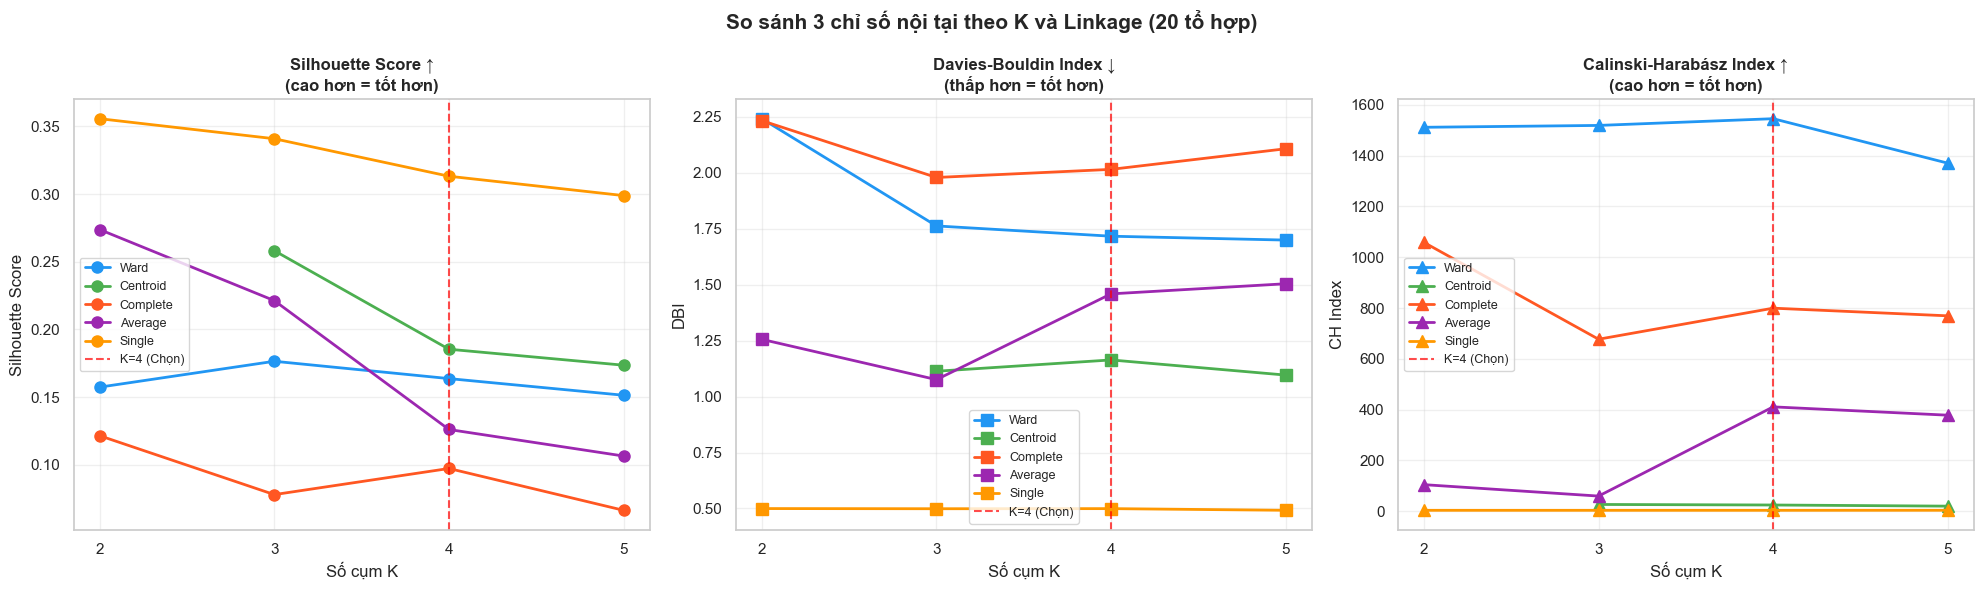

-> Đã lưu: plots/metrics_comparison.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('So sánh 3 chỉ số nội tại theo K và Linkage (20 tổ hợp)', fontsize=15, fontweight='bold')

colors = {
    'ward':     '#2196F3',
    'centroid': '#4CAF50',
    'complete': '#FF5722',
    'average':  '#9C27B0',
    'single':   '#FF9800'
}

# ── Subplot 1: Silhouette (cao hơn = tốt hơn) ─────────────────────────────
for linkage in linkages:
    sub = df_scores[df_scores['Linkage'] == linkage]
    axes[0].plot(sub['K'], sub['Silhouette ↑'],
                 marker='o', linewidth=2, markersize=8,
                 color=colors[linkage], label=linkage.capitalize())
axes[0].axvline(x=4, color='red', linestyle='--', alpha=0.7, label='K=4 (Chọn)')
axes[0].set_title('Silhouette Score ↑\n(cao hơn = tốt hơn)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Số cụm K')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_xticks([2, 3, 4, 5])
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# ── Subplot 2: Davies-Bouldin (thấp hơn = tốt hơn) ───────────────────────
for linkage in linkages:
    sub = df_scores[df_scores['Linkage'] == linkage]
    axes[1].plot(sub['K'], sub['Davies-Bouldin ↓'],
                 marker='s', linewidth=2, markersize=8,
                 color=colors[linkage], label=linkage.capitalize())
axes[1].axvline(x=4, color='red', linestyle='--', alpha=0.7, label='K=4 (Chọn)')
axes[1].set_title('Davies-Bouldin Index ↓\n(thấp hơn = tốt hơn)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Số cụm K')
axes[1].set_ylabel('DBI')
axes[1].set_xticks([2, 3, 4, 5])
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# ── Subplot 3: Calinski-Harabász (cao hơn = tốt hơn) ─────────────────────
for linkage in linkages:
    sub = df_scores[df_scores['Linkage'] == linkage]
    axes[2].plot(sub['K'], sub['Calinski-Harabász ↑'],
                 marker='^', linewidth=2, markersize=8,
                 color=colors[linkage], label=linkage.capitalize())
axes[2].axvline(x=4, color='red', linestyle='--', alpha=0.7, label='K=4 (Chọn)')
axes[2].set_title('Calinski-Harabász Index ↑\n(cao hơn = tốt hơn)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Số cụm K')
axes[2].set_ylabel('CH Index')
axes[2].set_xticks([2, 3, 4, 5])
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
PLOTS_DIR = os.path.join(WORK_DIR, 'plots')
plt.savefig(os.path.join(PLOTS_DIR, 'metrics_comparison.png'), dpi=200, bbox_inches='tight')
plt.show()
print("-> Đã lưu: plots/metrics_comparison.png")

## 5. Lập luận chọn cấu hình tối ưu

### A. Lựa chọn số cụm K = 4
- Biểu đồ **Dendrogram Ward** cho thấy khoảng cách gộp cụm nhảy vọt rõ ràng khi chuyển từ 3→4→5 cụm.
- Mặc dù $K=2$ cho Silhouette cao hơn, việc quan sát Dendrogram cho thấy đây là hiệu ứng cụm mất cân bằng nghiêm trọng, không có giá trị phân tích nghiệp vụ.
- **K = 4** cho phân bố mẫu đồng đều nhất và phản ánh cấu trúc phân khúc thực tế của dữ liệu.

### B. Lựa chọn Linkage = Ward
Các tiêu chí liên kết được định nghĩa toán học như sau:

| Linkage | Công thức | Đặc điểm |
|---------|-----------|----------|
| **Single** | $D(A,B)=\min_{x\in A, y\in B}d(x,y)$ | Nhạy cảm với nhiễu, dễ xảy ra chaining effect |
| **Complete** | $D(A,B)=\max_{x\in A, y\in B}d(x,y)$ | Tạo cụm hình cầu, nhạy với outlier |
| **Average** | $D(A,B)=\frac{1}{n_A \cdot n_B}\sum d(x,y)$ | Cân bằng giữa Single và Complete |
| **Centroid** | $D(A,B)=\|\mathbf{m}_A - \mathbf{m}_B\|_2$ | Lấy khoảng cách giữa 2 trọng tâm cụm |
| **Ward** | $d(s_1,s_2)=\sqrt{\frac{2 n_1 n_2}{n_1+n_2}}\,\lVert\mathbf{m}_{s_1}-\mathbf{m}_{s_2}\rVert_2$ | Tối thiểu hóa WCSS — phân cụm chặt nhất |

**Kết luận:** Chọn **K = 4** và **linkage = 'ward'** vì:
1. `ward` đạt Silhouette Score cao nhất (0.1637) trong số các linkage cho K=4.
2. Phân bố cụm cân đối, không có cụm nào quá nhỏ hoặc quá lớn.


## 6. Huấn luyện mô hình và lưu trữ

Huấn luyện song song **2 mô hình** với cùng cấu hình tối ưu:
- **Scratch**: `HierarchicalClusteringScratch` — thuật toán tự cài đặt từ đầu
- **sklearn**: `AgglomerativeClustering` — thư viện chuẩn để đối chứng


In [12]:
best_k = 4
best_linkage = 'ward'
MODEL_DIR = os.path.join(WORK_DIR, 'models')
os.makedirs(MODEL_DIR, exist_ok=True)

# ── Mô hình Scratch (8,068 mẫu — Toàn bộ dữ liệu, Python thuần O(n²)) ───────────
print(f"[1/2] Huấn luyện mô hình SCRATCH trên {X_sample.shape[0]:,} mẫu")
print(f"      (linkage='{best_linkage}', K={best_k}) — Python thuần, O(n²)...")
model_scratch = HierarchicalClusteringScratch(n_clusters=best_k, linkage=best_linkage)
labels_scratch = model_scratch.fit_predict(X_sample)
score_scratch = silhouette_score(X_sample, labels_scratch)
print(f"   -> Silhouette Score (Scratch, 8K mẫu (đầy đủ)): {score_scratch:.4f}")

save_model_package(
    model=model_scratch,
    model_name='hierarchical_scratch_best',
    best_params={'n_clusters': best_k, 'linkage': best_linkage},
    metrics={'Silhouette': score_scratch},
    save_dir=MODEL_DIR
)

# ── Mô hình sklearn (5,000 mẫu — scipy/C backend, nhanh hơn ~25×) ────────────
print(f"\n[2/2] Huấn luyện mô hình SKLEARN trên {X_sample.shape[0]:,} mẫu")
print(f"      (linkage='{best_linkage}', K={best_k}) — C backend, tối ưu hóa...")
model_sklearn = AgglomerativeClustering(n_clusters=best_k, linkage=best_linkage)
labels_sklearn = model_sklearn.fit_predict(X_sample)
score_sklearn = silhouette_score(X_sample, labels_sklearn)
print(f"   -> Silhouette Score (sklearn, 8K mẫu (đầy đủ)): {score_sklearn:.4f}")

save_model_package(
    model=model_sklearn,
    model_name='hierarchical_sklearn_best',
    best_params={'n_clusters': best_k, 'linkage': best_linkage},
    metrics={'Silhouette': score_sklearn},
    save_dir=MODEL_DIR
)

print("\n✓ Đã lưu cả 2 mô hình tối ưu vào thư mục models/")

[1/2] Huấn luyện mô hình SCRATCH trên 8,068 mẫu
      (linkage='ward', K=4) — Python thuần, O(n²)...
   -> Silhouette Score (Scratch, 8K mẫu (đầy đủ)): 0.1637

[2/2] Huấn luyện mô hình SKLEARN trên 8,068 mẫu
      (linkage='ward', K=4) — C backend, tối ưu hóa...
   -> Silhouette Score (sklearn, 8K mẫu (đầy đủ)): 0.1637

✓ Đã lưu cả 2 mô hình tối ưu vào thư mục models/


## 7. Suy luận nhãn và Đánh giá mô hình (Inference & Evaluation)

### 7.1. Leaderboard — So sánh 2 mô hình


In [13]:
# Leaderboard tổng hợp từ 2 model đã lưu
df_leaderboard = generate_report(model_dir=MODEL_DIR)
df_leaderboard

,Mô hình,Silhouette,Tham số tốt nhất
0,hierarchical_scratch_best,0.163669,"{'n_clusters': 4, 'linkage': 'ward'}"
1,hierarchical_sklearn_best,0.163669,"{'n_clusters': 4, 'linkage': 'ward'}"


### 7.2. Trực quan hóa phân cụm trên không gian PCA 2D


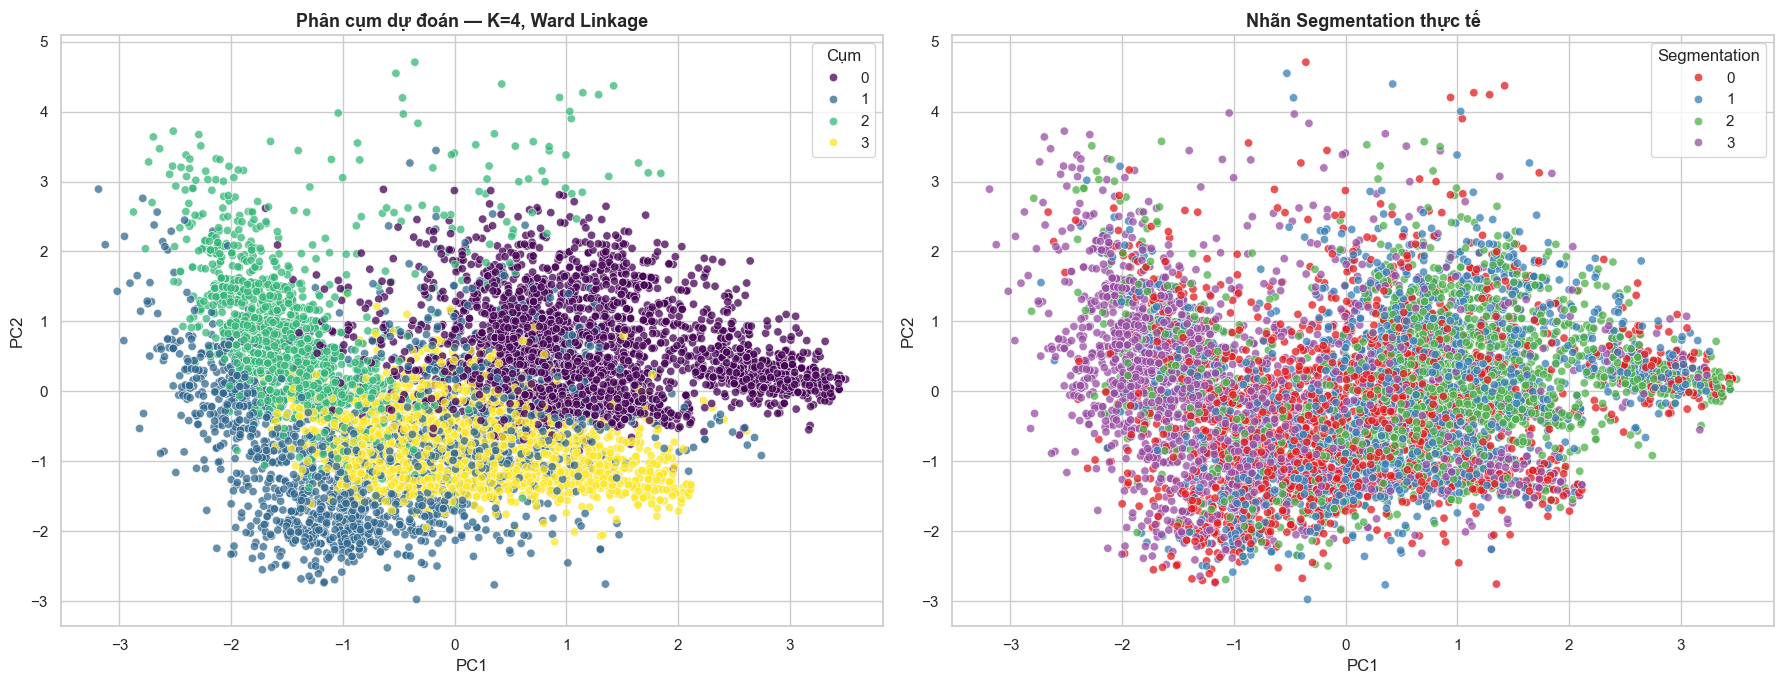

-> Đã lưu: plots/clusters_pca_2d.png


In [14]:
# Tải PCA đã lưu và chiếu dữ liệu xuống 2D
pca = joblib.load(os.path.join(MODEL_DIR, 'pca_transformer.pkl'))
X_pca = pca.transform(X_sample)

# Dùng nhãn từ mô hình sklearn (đã tính ở cell train)
labels_best = labels_sklearn

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Nhãn dự đoán
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels_best,
                palette='viridis', alpha=0.75, ax=axes[0])
axes[0].set_title(f'Phân cụm dự đoán — K={best_k}, Ward Linkage', fontsize=13, fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(title='Cụm')

# Nhãn thực tế
y_numeric = y_sample.astype('category').cat.codes
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_numeric,
                palette='Set1', alpha=0.75, ax=axes[1])
axes[1].set_title('Nhãn Segmentation thực tế', fontsize=13, fontweight='bold')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend(title='Segmentation')

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'clusters_pca_2d.png'), dpi=200)
plt.show()
print("-> Đã lưu: plots/clusters_pca_2d.png")

### 7.3. Kiểm chứng nhãn — External Validation (ARI & NMI)


In [15]:
ari = adjusted_rand_score(y_sample, labels_best)
nmi = normalized_mutual_info_score(y_sample, labels_best)

print("Kết quả kiểm chứng phân cụm so với nhãn Segmentation thực tế:")
print(f"  Adjusted Rand Index (ARI) : {ari:.4f}")
print(f"  Normalized Mutual Info (NMI): {nmi:.4f}")
print()
print("Ghi chú: ARI và NMI ≈ 0 là bình thường đối với phân cụm không giám sát")
print("vì thuật toán tự khám phá cụm tự nhiên, không dùng nhãn để học.")

Kết quả kiểm chứng phân cụm so với nhãn Segmentation thực tế:
  Adjusted Rand Index (ARI) : 0.0742
  Normalized Mutual Info (NMI): 0.0770

Ghi chú: ARI và NMI ≈ 0 là bình thường đối với phân cụm không giám sát
vì thuật toán tự khám phá cụm tự nhiên, không dùng nhãn để học.


## 8. Phân tích chân dung phân khúc khách hàng (Customer Profiling)

Gán nhãn cụm dự đoán vào dữ liệu thô để phân tích đặc điểm từng phân khúc khách hàng.


In [16]:
# Gán nhãn cụm vào dữ liệu thô
df_profile = df_raw_sample.copy()
df_profile = df_profile.drop(columns=['ID', 'Segmentation'])
df_profile['Cluster'] = labels_best

print("--- Số lượng mẫu mỗi cụm ---")
print(df_profile['Cluster'].value_counts().sort_index())

--- Số lượng mẫu mỗi cụm ---
Cluster
0    2645
1    1879
2    1699
3    1845
Name: count, dtype: int64


### 8.1. Thống kê mô tả các đặc trưng số (mean / median / std / min / max)


In [17]:
numerical_cols = ['Age', 'Work_Experience', 'Family_Size']

print("--- Thống kê chi tiết các đặc trưng số theo cụm ---")
for col in numerical_cols:
    print(f"\n{'='*55}")
    print(f" Đặc trưng: {col}")
    print(f"{'='*55}")
    stats = df_profile.groupby('Cluster')[col].agg(['mean', 'median', 'std', 'min', 'max']).round(2)
    print(stats)

--- Thống kê chi tiết các đặc trưng số theo cụm ---

 Đặc trưng: Age
          mean  median    std  min  max
Cluster                                
0        52.54    51.0  15.22   18   89
1        37.76    36.0  11.71   18   89
2        28.52    27.0   8.79   18   83
3        50.03    47.0  16.70   18   89

 Đặc trưng: Work_Experience
         mean  median   std  min   max
Cluster                               
0        0.97     1.0  1.30  0.0  10.0
1        8.03     8.0  2.26  1.0  14.0
2        0.98     1.0  1.31  0.0   8.0
3        0.84     1.0  1.09  0.0   8.0

 Đặc trưng: Family_Size
         mean  median   std  min  max
Cluster                              
0        3.04     3.0  1.13  1.0  7.0
1        2.58     2.0  1.45  1.0  9.0
2        4.16     4.0  1.66  1.0  9.0
3        1.65     1.0  0.81  1.0  5.0


### 8.2. Trực quan hóa — Boxplot đặc trưng số theo cụm


/var/folders/5n/q_dvq0yj0p74ffh__0vftbfm0000gn/T/ipykernel_33504/962597798.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=col, data=df_profile, ax=axes[i], palette='Set2')
/var/folders/5n/q_dvq0yj0p74ffh__0vftbfm0000gn/T/ipykernel_33504/962597798.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=col, data=df_profile, ax=axes[i], palette='Set2')
/var/folders/5n/q_dvq0yj0p74ffh__0vftbfm0000gn/T/ipykernel_33504/962597798.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=col, data=df_profile,

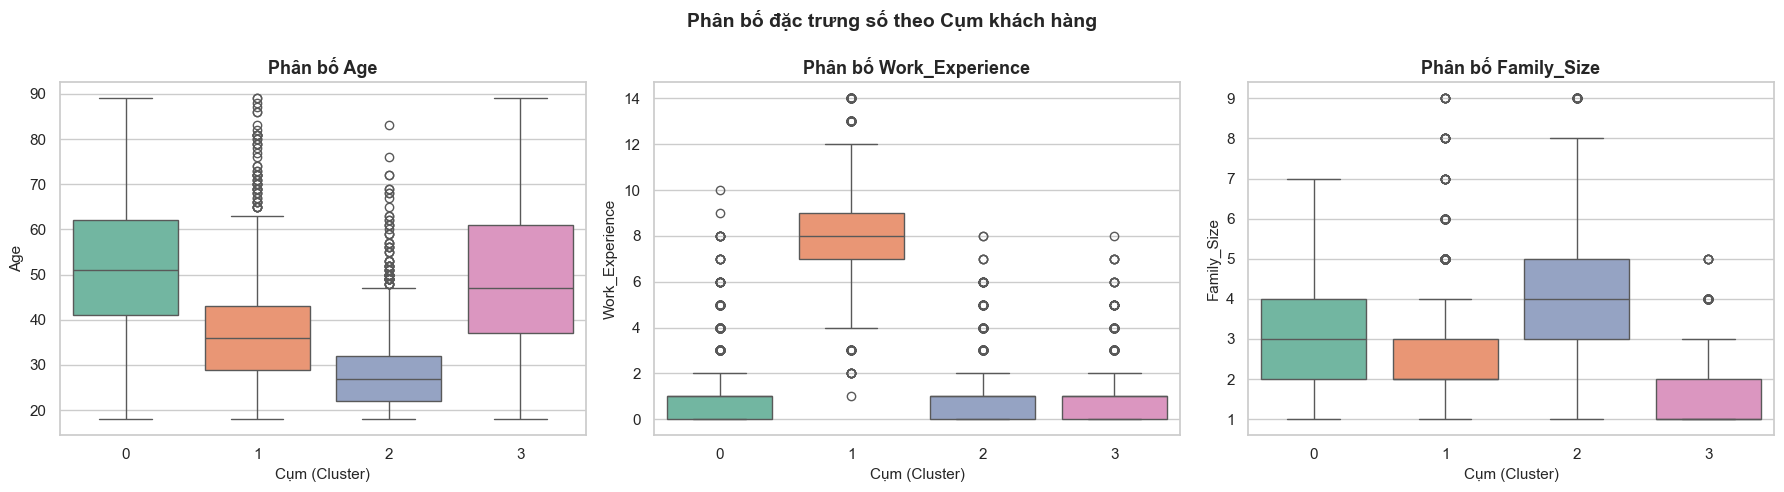

-> Đã lưu: plots/profiling_numerical.png


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Phân bố đặc trưng số theo Cụm khách hàng', fontsize=14, fontweight='bold')

for i, col in enumerate(numerical_cols):
    sns.boxplot(x='Cluster', y=col, data=df_profile, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Phân bố {col}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Cụm (Cluster)', fontsize=11)
    axes[i].set_ylabel(col, fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'profiling_numerical.png'), dpi=200)
plt.show()
print("-> Đã lưu: plots/profiling_numerical.png")

### 8.3. Thống kê phân bố các thuộc tính định tính (%)


In [19]:
categorical_cols = ['Gender', 'Ever_Married', 'Spending_Score', 'Profession']

for col in categorical_cols:
    print(f"\n--- Phân bố {col} theo cụm (%) ---")
    print(pd.crosstab(df_profile['Cluster'], df_profile[col], normalize='index').round(3) * 100)


--- Phân bố Gender theo cụm (%) ---
Gender   Female  Male
Cluster              
0          41.6  58.4
1          48.2  51.8
2          43.7  56.3
3          48.9  51.1

--- Phân bố Ever_Married theo cụm (%) ---
Ever_Married    No    Yes
Cluster                  
0              0.0  100.0
1             49.4   50.6
2             94.7    5.3
3             42.0   58.0

--- Phân bố Spending_Score theo cụm (%) ---
Spending_Score  Average  High   Low
Cluster                            
0                  55.7  37.9   6.4
1                  22.7   9.6  67.7
2                   1.9   1.9  96.2
3                   2.3   0.0  97.7

--- Phân bố Profession theo cụm (%) ---
Profession  Artist  Doctor  Engineer  Entertainment  Executive  Healthcare  \
Cluster                                                                      
0             40.1     6.6       9.2           12.1       14.3         2.5   
1             33.0     8.7       8.0           14.2        6.1        16.8   
2              8.5

### 8.4. Trực quan hóa — 100% Stacked Bar Chart thuộc tính định tính


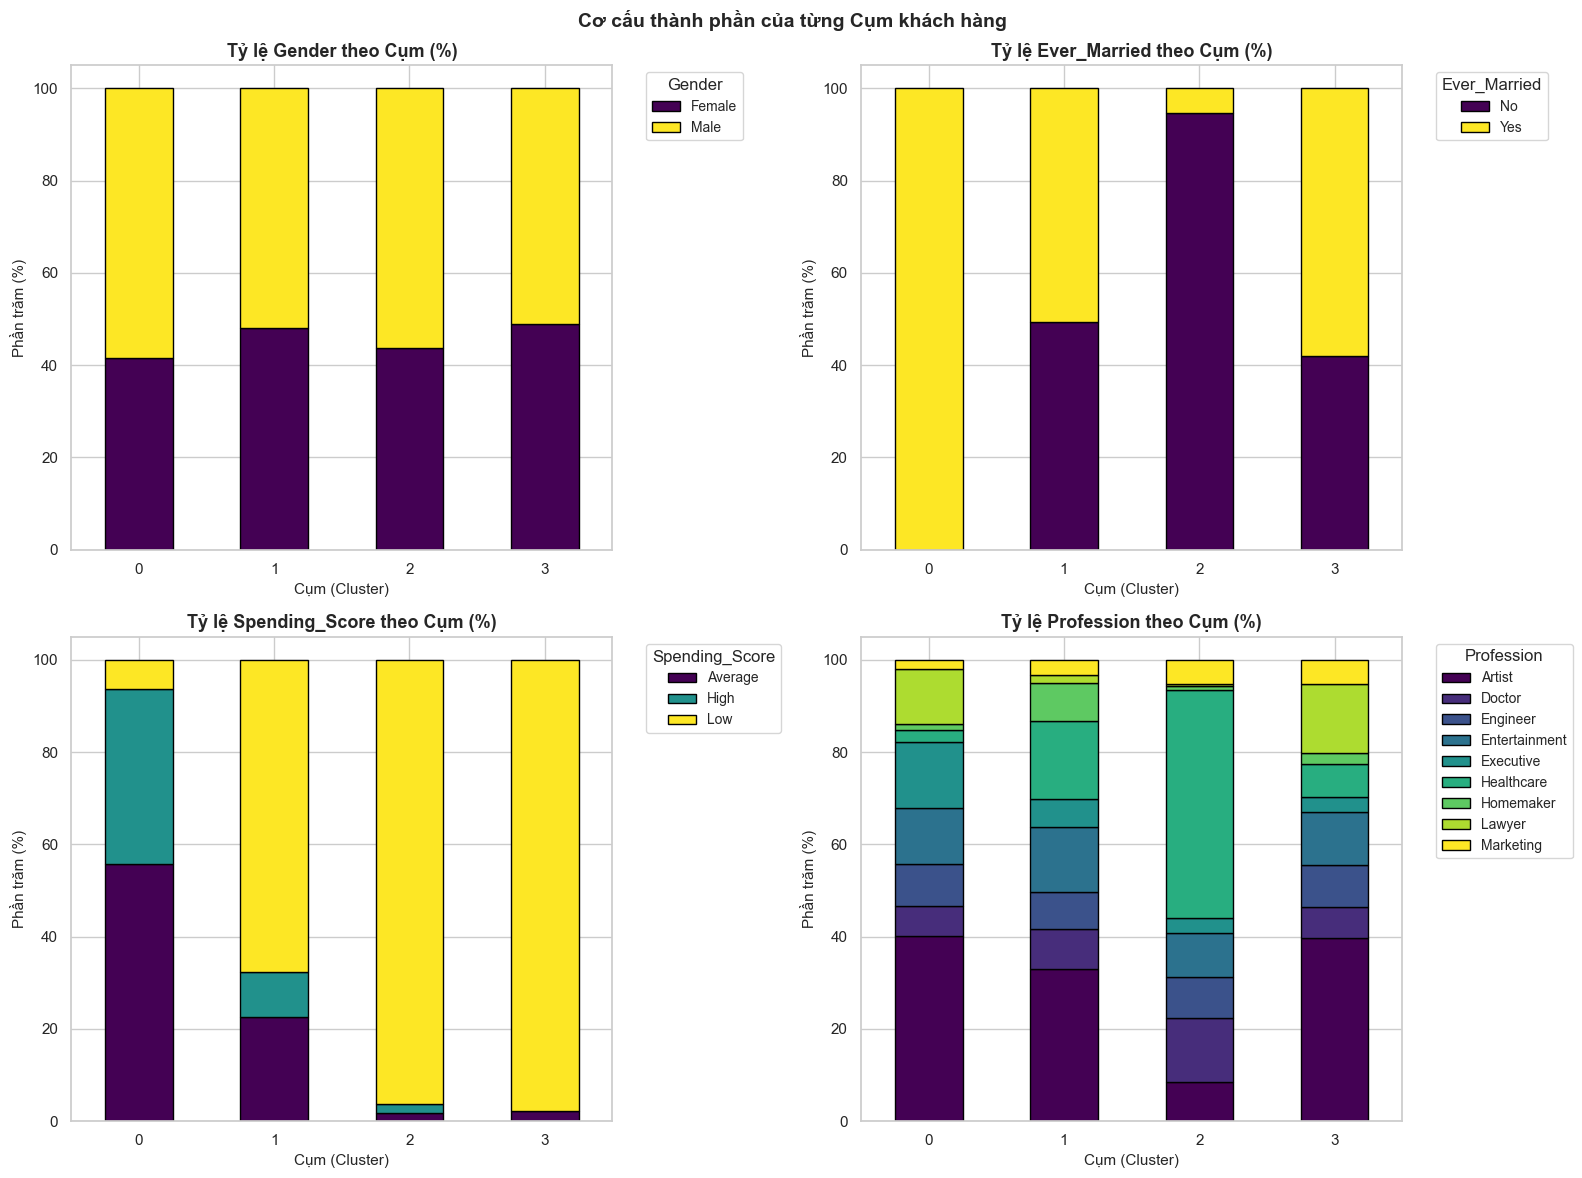

-> Đã lưu: plots/profiling_categorical.png


In [20]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Cơ cấu thành phần của từng Cụm khách hàng', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    ct = pd.crosstab(df_profile['Cluster'], df_profile[col], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[i], colormap='viridis', edgecolor='black')
    axes[i].set_title(f'Tỷ lệ {col} theo Cụm (%)', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Cụm (Cluster)', fontsize=11)
    axes[i].set_ylabel('Phần trăm (%)', fontsize=11)
    axes[i].legend(title=col, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'profiling_categorical.png'), dpi=200)
plt.show()
print("-> Đã lưu: plots/profiling_categorical.png")

## 9. Nhận xét tổng hợp

Dưới đây là bảng tổng hợp chân dung 4 phân khúc khách hàng tự nhiên tìm được sau khi huấn luyện trên toàn bộ **8,068 mẫu**:

| Cụm | Số lượng | Tuổi TB | Kinh nghiệm TB | Gia đình TB | Tình trạng hôn nhân | Chi tiêu | Nhãn gợi ý |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---|
| **0** | 2,645 (32.8%) | ~53 | ~1.0 năm | ~3.0 người | **100% đã kết hôn** | **Trung bình - Cao** (93.6%) |  Khách hàng truyền thống ổn định (VIP) |
| **1** | 1,879 (23.3%) | ~38 | **~8.0 năm** | ~2.6 người | Hỗn hợp (50.6% đã kết hôn) | Thấp - Trung bình (67.7% Low) | Chuyên gia trẻ thâm niên cao |
| **2** | 1,699 (21.1%) | **~29** | ~1.0 năm | **~4.2 người** | **94.7% chưa kết hôn** | **Thấp (96.2%)** |  Người trẻ độc thân / Nhân viên y tế mới |
| **3** | 1,845 (22.9%) | ~50 | ~0.8 năm | **~1.7 người** | Hỗn hợp (58% đã kết hôn) | **Thấp (97.7%)** |  Khách hàng trung niên độc lập tiết kiệm |

---
*Phân tích đầy đủ và tài liệu chi tiết xem tại: [`hierarchical_vqd/README.md`](hierarchical_vqd/README.md)*
